# Eploratory Data Analyst House Price: Pola Untuk Memprediksi Harga Rumah
Di dataset ini sempat hilang sourcenya, tapi harusnya yang ini. Study case: House price in Boston

## Informasi Dataset
- Judul dataset: Boston house price
- Sumber data: Kaggle - https://www.kaggle.com/datasets/fedesoriano/the-boston-houseprice-data/data
- dataset terdiri dari 14 kolom dan 506 baris

## Keterangan Data
- CRIM: Tingkat Kejahatan Per Kapita berdasarkan kota (dtype=float64)
- ZN: Persentase lahan perumahan yang diperuntukkan untuk kavling dengan luas lebih dari 25.000 kaki persegi (dtype=float64)
- INDUS: Persentase luas lahan usaha non-ritel per kota (dtype=float64)
- CHAS: Variabel sementara Charles River, 1 jika batas wilayah berbatasan dengan sungai; 0 jika tidak (dtype=int64)
- NOX: Konsentrasi oksida nitrat (bagian per 10 juta) (dtype=float64)
- RM: Jumlah rata-rata kamar per rumah tangga (dtype=float64)
- AGE: proportion of owner-occupied units built prior to 1940 (proportion of owner-occupied units built prior to 1940) (dtype=float64)
- DIS: Jarak tempuh ke lima pusat pekerjaan di Boston (dtype=float64)
- RAD: Indeks Aksesibilitas Jalan Raya Radial (dtype=int64)
- TAX: full-value property-tax rate per $10,000 $10k full-value property-tax rate per $10,000 $10k (dtype=int64)
- PTRATIO: Perbandingan jumlah siswa dan guru per kota (dtype=float64)
- B: Hasil dari persamaan B = 1000(Bk - 0,63)² di mana Bk adalah proporsi penduduk kulit hitam di setiap kota. (dtype=float64)
- LSTAT: presentase status sosial yang lebih rendah dari populasi, Nilai median rumah yang dimiliki dan ditempati oleh pemiliknya dalam ribuan dolar $ satuannya ribuan dolar kayaknya (dtype=float64)
- MEDV: Median value of owner-occupied homes in $1000's $ (dtype=float64) (Target)

## Import Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load And Overview dataset

In [4]:
df = pd.read_csv(r"C:\Belajar Pemrograman\Artificial Intelligence\Datasets\DS_002_HousePrice\boston.csv")
print('Baris dan kolom data: ', df.shape)
df.info()
df.head()

Baris dan kolom data:  (506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## Cek Missing Value and Duplicate data
Info: Data bersih

In [ ]:
df.isnull().sum()
df.duplicated().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

## Cek Distribusi Target
Info: Distribusi data Normal

In [8]:
mean = df['MEDV'].mean()
median = df['MEDV'].median()
print('Rata Rata dari kolom MEDV: ',mean)
print('Median dari kolom MEDV: ',median)

Rata Rata dari kolom MEDV:  22.532806324110677
Median dari kolom MEDV:  21.2


## Menyusun Hipotesis
1. MEDV berdasarkan RM
2. MEDV berdasarkan LSTAT
3. MEDV berdasarkan PTRATIO
4. MEdV berdasarkan CRIM

# 1. MEDV by RM (Rata rata kamar per rumah)
Hasil observasi: walaupun tidak semua atau keseluruhan rumah tapi data yang tersedia menunjukan bahwa rata rata harga rumah turut dipengaruhi oleh rata rata tempat tidur

C:\Users\Louis Immanuel A\AppData\Local\Temp\ipykernel_40012\1878228996.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


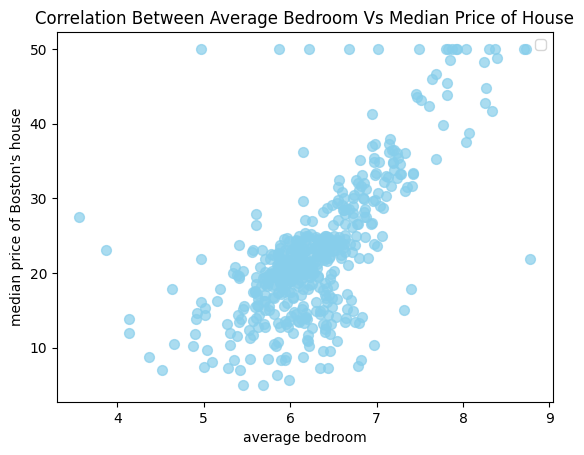

In [ ]:
x1 = np.array(df['RM']) 
y1 = np.array(df['MEDV']) 

plt.scatter(x1, y1, color='skyblue',
                  alpha=0.7, 
                  s = 50, 
                  ) 

plt.title('Correlation Between Average Bedroom Vs Median Price of House')
plt.xlabel('average bedroom')
plt.ylabel("median price of Boston's house")

plt.show()

## 2. MEDV by LSTAT
Hasil Observasi: Walaupun tidak keseluruhan rumah tetapi data menunjukan kalau angka LSTAT-nya tinggi (banyak masyarakat kelas bawah), harga rumah di daerah situ (MEDV) biasanya cenderung lebih murah.

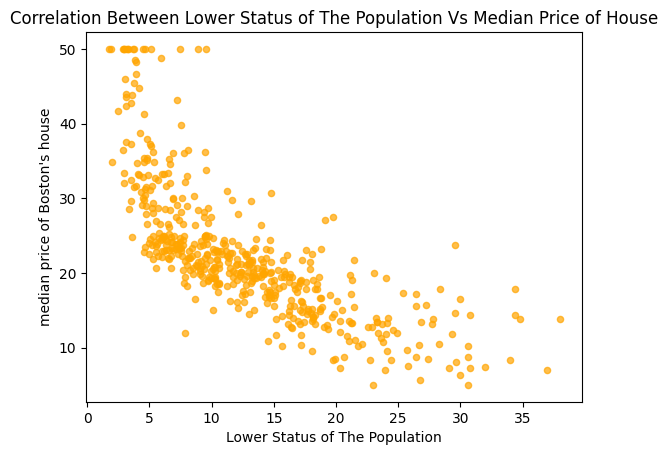

In [18]:
x1 = np.array(df['LSTAT']) 
y1 = np.array(df['MEDV']) 

plt.scatter(x1, y1, color='orange',
                  alpha=0.7, 
                  s = 20, 
                  ) 

plt.title('Correlation Between Lower Status of The Population Vs Median Price of House')
plt.xlabel('Lower Status of The Population')
plt.ylabel("median price of Boston's house")

plt.show()

## 3. MEDV by PTRATIO
Hasil Obseservasi: Data/tren menunjukan bahwa harga rumah di area tersebut adanya korelasi lebih rendah yang negatif antara perbandingan harga rumah dengan perbandingan guru dan murid (PTRATIO) artinya makin padat sekolah, makin murah rumah di are tersebut

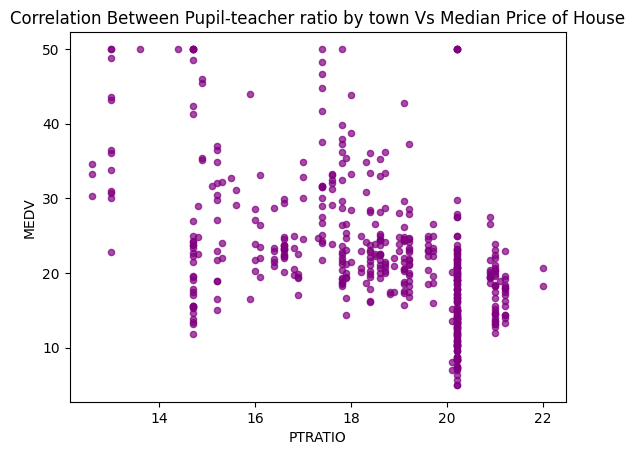

In [22]:
x1 = np.array(df['PTRATIO']) 
y1 = np.array(df['MEDV']) 

plt.scatter(x1, y1, color='purple',
                  alpha=0.7, 
                  s = 20, 
                  ) 

plt.title('Correlation Between Pupil-teacher ratio by town Vs Median Price of House')
plt.xlabel('PTRATIO')
plt.ylabel("MEDV")

plt.show()

## 4. MEDV by CRIM
Hasil Observasi: ketika tingkat kejahatan masih tergolong rendah harga rumah masih menyebar secara variasi dari murah menengah hingga tergolong tinggi tetapi ketika tingkat kejahatan mulai menengah atau tinggi harga rumah otomatis anjlok dan mentok di harga rendah

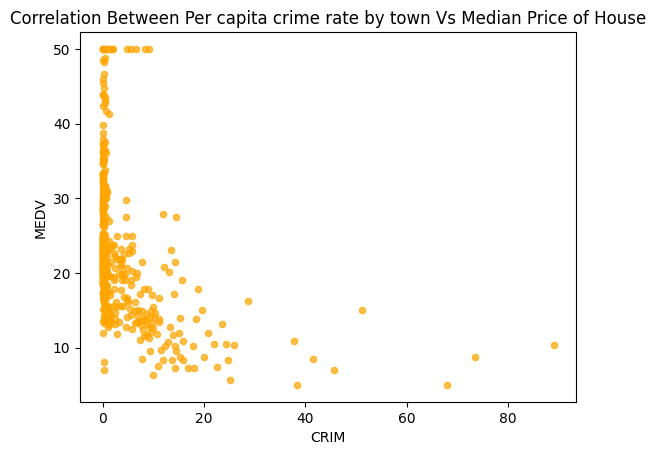

In [23]:
x1 = np.array(df['CRIM']) 
y1 = np.array(df['MEDV']) 

plt.scatter(x1, y1, color='orange',
                  alpha=0.7, 
                  s = 20, 
                  ) 

plt.title('Correlation Between Per capita crime rate by town Vs Median Price of House')
plt.xlabel('CRIM')
plt.ylabel("MEDV")

plt.show()

## Kesimpulan
1. RM (Rata-rata Jumlah Kamar) - Bikin Harga Naik
Ini punya korelasi positif. Semakin banyak jumlah kamar di sebuah rumah, harga jualnya cenderung semakin mahal. Ukuran/kapasitas rumah berbanding lurus dengan nilainya.

2. LSTAT (Status Sosial Lingkungan) - Penentu Harga Jatuh Paling Kuat
Ini punya korelasi negatif yang paling jelas. Semakin tinggi persentase warga kelas menengah ke bawah di suatu area, harga rumah di sekitarnya bakal semakin merosot. Singkatnya, lingkungan yang kurang sejahtera bikin nilai properti ikut turun.

3. CRIM (Tingkat Kriminalitas) - Batas Maksimal Harga
Korelasi negatif. Tingkat kejahatan bertindak seperti "plafon" atau penahan harga. Kalau daerahnya aman (kejahatan mendekati nol), harga rumah bisa sangat bervariasi dari yang termurah sampai termahal. Tapi, begitu daerah tersebut punya tingkat kejahatan menengah sampai tinggi, harga rumah dipastikan anjlok dan mentok di harga murah.

4. PTRATIO (Kepadatan Sekolah) - Pengaruh Tambahan
Korelasi negatif, tapi sifatnya lebih lemah dibandingkan LSTAT. Daerah yang sekolahnya terlalu padat (rasio murid per guru tinggi) cenderung memiliki harga rumah yang lebih murah. Ini menunjukkan kalau kualitas fasilitas pendidikan di sekitar lingkungan juga ikut jadi bahan pertimbangan harga.